In [1]:
!pip install shap
!pip install polars

  Using cached shap-0.51.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (25 kB)
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.51.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (1.1 MB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [shap]2/3 [shap]]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import math
import pandas as pd
import polars as pl
import numpy as np
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import time
import joblib
import boto3
import tempfile
import logging

In [2]:
def save_model_to_s3(model, bucket_name, object_key):
    s3_client = boto3.client('s3')
    try:
        with tempfile.TemporaryFile() as fp:
            joblib.dump(model, fp)
            fp.seek(0) # Rewind the file pointer to the beginning
            s3_client.put_object(Body=fp.read(), Bucket=bucket_name, Key=object_key)
            logging.info(f'{object_key} saved to s3 bucket {bucket_name}')
    except Exception as e:
        logging.exception(e)
        raise

In [3]:
# Read aggregated data from S3
df = pl.read_parquet("s3://msds-26.2-data/clean/combined_recovery_data_aggregated_with_full_features.parquet")

In [5]:
df.describe()

statistic,hashed_fc,gl_product_group,start,end,week_date,year,month,week,num_records,units_RETAIL,units_FBA,units_hazmat,units_food,units_non_food,units_pet_food,units_total,cogs_total,weight_total,country,country_state,zip_code,site_type,site_category,units_recovered,units_remove_return,units_bintool_donations,units_donations,units_warehouse_deals_and_gr,units_liquidations,units_sales,units_return_to_vendor,units_bintool_theft,units_remove_liquidate,units_bintool_remove_liquidate,share_food,share_non_food,…,site_units_return_to_vendor_week_ewma_1a,site_units_bintool_theft_week_ewma_5a,site_units_bintool_theft_week_ewma_1a,site_units_remove_liquidate_week_ewma_5a,site_units_remove_liquidate_week_ewma_1a,site_units_bintool_remove_liquidate_week_ewma_5a,site_units_bintool_remove_liquidate_week_ewma_1a,site_units_share_week_ewma_5a,site_units_share_week_ewma_1a,site_weight_share_week_ewma_5a,site_weight_share_week_ewma_1a,site_recovered_share_week_ewma_5a,site_recovered_share_week_ewma_1a,site_prob_recovered_week_ewma_5a,site_prob_recovered_week_ewma_1a,site_prob_remove_return_week_ewma_5a,site_prob_remove_return_week_ewma_1a,site_prob_bintool_donations_week_ewma_5a,site_prob_bintool_donations_week_ewma_1a,site_prob_donations_week_ewma_5a,site_prob_donations_week_ewma_1a,site_prob_warehouse_deals_and_gr_week_ewma_5a,site_prob_warehouse_deals_and_gr_week_ewma_1a,site_prob_liquidations_week_ewma_5a,site_prob_liquidations_week_ewma_1a,site_prob_sales_week_ewma_5a,site_prob_sales_week_ewma_1a,site_prob_return_to_vendor_week_ewma_5a,site_prob_return_to_vendor_week_ewma_1a,site_prob_bintool_theft_week_ewma_5a,site_prob_bintool_theft_week_ewma_1a,site_prob_remove_liquidate_week_ewma_5a,site_prob_remove_liquidate_week_ewma_1a,site_prob_bintool_remove_liquidate_week_ewma_5a,site_prob_bintool_remove_liquidate_week_ewma_1a,week_sin,week_cos
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""8768870""",8.76887e6,"""8768870""","""8768870""","""8768870""",8.76887e6,8.76887e6,8.76887e6,8.76887e6,8.76887e6,8.76887e6,8.76887e6,8.76887e6,8.76887e6,8.76887e6,8.76887e6,8.76887e6,8.76887e6,"""8768870""","""5348273""","""5345025""","""5348273""","""5348273""",8.76887e6,8.76887e6,8.76887e6,8.76887e6,8.76887e6,8.76887e6,8.76887e6,8.76887e6,8.76887e6,8.76887e6,8.76887e6,8.76887e6,8.76887e6,…,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,7.763703e6,8.76887e6,8.76887e6
"""null_count""","""0""",0.0,"""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""3420597""","""3423845""","""3420597""","""3420597""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,1.005167e6,0.0,0.0
"""mean""",null,263.812529,"""2022-07-08 12:51:39.657037""","""2025-09-24 14:17:56.048521""","""2024-02-19 12:15:38.225883""",2023.641557,6.631453,26.71201,6.359705,1366.794289,2475.81044,283.080132,258.342682,3527.82653,56.435517,3842.604729,30084.686511,4.1663e6,null,null,null,null,null,194.247269,0.309518,0.252125,24.666947,9.718359,50.623462,3648.357461,62.875313,0.169848,37.890933,7.740764,0.046625,0.948

In [6]:
df.columns

['hashed_fc',
 'gl_product_group',
 'start',
 'end',
 'week_date',
 'year',
 'month',
 'week',
 'num_records',
 'units_RETAIL',
 'units_FBA',
 'units_hazmat',
 'units_food',
 'units_non_food',
 'units_pet_food',
 'units_total',
 'cogs_total',
 'weight_total',
 'country',
 'country_state',
 'zip_code',
 'site_type',
 'site_category',
 'units_recovered',
 'units_remove_return',
 'units_bintool_donations',
 'units_donations',
 'units_warehouse_deals_and_gr',
 'units_liquidations',
 'units_sales',
 'units_return_to_vendor',
 'units_bintool_theft',
 'units_remove_liquidate',
 'units_bintool_remove_liquidate',
 'share_food',
 'share_non_food',
 'share_pet_food',
 'share_RETAIL',
 'share_FBA',
 'share_hazmat',
 'prob_recovered',
 'prob_remove_return',
 'prob_bintool_donations',
 'prob_donations',
 'prob_warehouse_deals_and_gr',
 'prob_liquidations',
 'prob_sales',
 'prob_return_to_vendor',
 'prob_bintool_theft',
 'prob_remove_liquidate',
 'prob_bintool_remove_liquidate',
 'avg_cogs_per_unit',

# Propensity to Waste

In [4]:
# Define features and target variable
identity_cols = [
    "hashed_fc", "gl_product_group", "week_date",
]

gl_composition_cols = [
    "share_food", "share_non_food", "share_pet_food",
    "share_RETAIL", "share_FBA", "share_hazmat",
]

gl_volume_cols = [
    "units_total", "cogs_total", "weight_total",
    "avg_cogs_per_unit", "avg_weight_per_unit", "cogs_per_unit_weight",
]

gl_at_site_cols = [
    "site_units_share_week", "site_weight_share_week",
]

site_context_cols = [
    "site_units_total_week", "site_weight_total_week",
    "site_type", "site_category", "country", "country_state",
]

temporal_site_context_cols = ['site_units_total_week_lag_1w',
 'site_units_total_week_lag_4w',
 'site_units_total_week_lag_12w',
 'site_units_total_week_lag_13w',
 'site_units_total_week_lag_52w',
 'site_weight_total_week_lag_1w',
 'site_weight_total_week_lag_4w',
 'site_weight_total_week_lag_12w',
 'site_weight_total_week_lag_13w',
 'site_weight_total_week_lag_52w',
 'site_prob_recovered_week_lag_1w',
 'site_prob_recovered_week_lag_4w',
 'site_prob_recovered_week_lag_12w',
 'site_prob_recovered_week_lag_13w',
 'site_prob_recovered_week_lag_52w',
 'site_prob_recovered_week_rolling_4w',
 'site_prob_recovered_week_rolling_12w',
'site_prob_recovered_week_rolling_26w',
 'site_prob_recovered_week_rolling_52w',
]

calendar_cols = [
    "month", "week"
]

temporal_composition_cols = [
 'share_RETAIL_lag_1w',
 'share_RETAIL_lag_4w',
 'share_RETAIL_lag_12w',
 'share_RETAIL_lag_13w',
 'share_RETAIL_lag_52w',
 'share_FBA_lag_4w',
 'share_FBA_lag_12w',
 'share_FBA_lag_13w',
 'share_FBA_lag_52w',
 'share_hazmat_lag_1w',
 'share_hazmat_lag_4w',
 'share_hazmat_lag_12w',
 'share_hazmat_lag_13w',
 'share_hazmat_lag_52w',
 'share_food_lag_1w',
 'share_food_lag_4w',
 'share_food_lag_12w',
 'share_food_lag_13w',
 'share_food_lag_52w',
 'share_non_food_lag_1w',
 'share_non_food_lag_4w',
 'share_non_food_lag_12w',
 'share_non_food_lag_13w',
 'share_non_food_lag_52w',
 'share_pet_food_lag_1w',
 'share_pet_food_lag_4w',
 'share_pet_food_lag_12w',
 'share_pet_food_lag_13w',
 'share_pet_food_lag_52w',
 'share_food_rolling_4w',
 'share_food_rolling_12w',
 'share_non_food_rolling_4w',
 'share_non_food_rolling_12w',
 'share_pet_food_rolling_4w',
 'share_pet_food_rolling_12w',
 'share_RETAIL_rolling_4w',
 'share_RETAIL_rolling_12w',
 'share_FBA_rolling_4w',
 'share_FBA_rolling_12w',
 'share_hazmat_rolling_4w',
 'share_hazmat_rolling_12w',
 'share_food_rolling_26w',
 'share_food_rolling_52w',
 'share_non_food_rolling_26w',
 'share_non_food_rolling_52w',
 'share_pet_food_rolling_26w',
 'share_pet_food_rolling_52w',
 'share_RETAIL_rolling_26w',
 'share_RETAIL_rolling_52w',
 'share_FBA_rolling_26w',
 'share_FBA_rolling_52w',
 'share_hazmat_rolling_26w',
 'share_hazmat_rolling_52w',
 'share_RETAIL_ewma_5a',
 'share_RETAIL_ewma_1a',
 'share_FBA_ewma_5a',
 'share_FBA_ewma_1a',
 'share_hazmat_ewma_5a',
 'share_hazmat_ewma_1a',
 'share_food_ewma_5a',
 'share_food_ewma_1a',
 'share_non_food_ewma_5a',
 'share_non_food_ewma_1a',
 'share_pet_food_ewma_5a',
 'share_pet_food_ewma_1a',
]

temporal_volume_cols = [
 'units_total_lag_1w',
 'units_total_lag_4w',
 'units_total_lag_12w',
 'units_total_lag_13w',
 'units_total_lag_52w',
 'cogs_total_lag_1w',
 'cogs_total_lag_4w',
 'cogs_total_lag_12w',
 'cogs_total_lag_13w',
 'cogs_total_lag_52w',
 'weight_total_lag_1w',
 'weight_total_lag_4w',
 'weight_total_lag_12w',
 'weight_total_lag_13w',
 'weight_total_lag_52w',
 'units_total_rolling_4w',
 'units_total_rolling_12w',
 'cogs_total_rolling_4w',
 'cogs_total_rolling_12w',
 'weight_total_rolling_4w',
 'weight_total_rolling_12w',
 'units_total_rolling_26w',
 'units_total_rolling_52w',
 'cogs_total_rolling_26w',
 'cogs_total_rolling_52w',
 'weight_total_rolling_26w',
 'weight_total_rolling_52w',
 'units_total_ewma_5a',
 'units_total_ewma_1a',
 'cogs_total_ewma_5a',
 'cogs_total_ewma_1a',
 'weight_total_ewma_5a',
 'weight_total_ewma_1a'
]

temporal_probability_cols = [
 'prob_recovered_lag_1w',
 'prob_recovered_lag_4w',
 'prob_recovered_lag_12w',
 'prob_recovered_lag_13w',
 'prob_recovered_lag_52w',
 'prob_recovered_rolling_26w',
 'prob_recovered_rolling_52w',
 'prob_recovered_rolling_4w',
 'prob_recovered_rolling_12w',
 'prob_recovered_ewma_5a',
 'prob_recovered_ewma_1a',
]

In [5]:
target_col = "prob_recovered"

feature_cols = (gl_composition_cols + gl_volume_cols + gl_at_site_cols + site_context_cols + temporal_site_context_cols+ calendar_cols + temporal_composition_cols + temporal_volume_cols + temporal_probability_cols)

In [6]:
print(f"Total features: {len(feature_cols)}")

Total features: 150


In [7]:
# Train on 2022-2024, test on 2025
df_train = df.filter(pl.col("year") < 2025)
df_test = df.filter(pl.col("year") == 2025)

## Train on Logit Transform Proportion

In [10]:
EPS = 1e-6  # boundary guard

def logit(p: np.ndarray) -> np.ndarray:
    """Map probability [0, 1] → real line (-inf, +inf)."""
    p = np.clip(p, EPS, 1 - EPS)
    return np.log(p / (1 - p))

def sigmoid(x: np.ndarray) -> np.ndarray:
    """Inverse logit: map real line → probability [0, 1]."""
    return 1 / (1 + np.exp(-x))

In [11]:
# Custom early-stopping eval metric
def prob_mae(y_pred: np.ndarray, y_true: np.ndarray) -> float:
    """
    Custom eval metric for XGBRegressor (sklearn API).
    Must return a plain float — XGBoost uses the function name as the metric label.
    Both y_pred and y_true are in logit space — back-transform before computing MAE.
    """
    p_true = sigmoid(y_true)
    p_pred = sigmoid(y_pred)
    return float(np.mean(np.abs(p_pred - p_true)))

In [12]:
# categorical columns that need dtype casting 
CAT_COLS = [
    'hashed_fc',
    'gl_product_group',
    'country',
    'country_state',
    'site_type',
    'site_category',
]

# helper: cast categoricals in-place 
def cast_categoricals(df: pd.DataFrame) -> pd.DataFrame:
    for col in CAT_COLS:
        if col in df.columns:
            df[col] = df[col].astype("category")
    return df

In [14]:
def train_model(
    df_train: pl.DataFrame,
    df_test: pl.DataFrame,
    feature_cols: list[str],
    target_col: str,
    n_estimators: int = 2000,      
    early_stopping_rounds: int = 50,
    verbose_eval: int = 100
):

    start = time.perf_counter()

    X_train = cast_categoricals(df_train.select(['hashed_fc', 'gl_product_group'] + feature_cols).to_pandas())
    X_val   = cast_categoricals(df_test.select(['hashed_fc', 'gl_product_group'] + feature_cols).to_pandas())

    y_train = df_train[target_col].to_pandas().values
    y_val   = df_test[target_col].to_pandas().values

    # logit-transform the target 
    y_train_logit = logit(y_train)
    y_val_logit   = logit(y_val)

   
    # fit model 
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=n_estimators,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        enable_categorical=True,
        random_state=42,
        early_stopping_rounds=early_stopping_rounds,
        eval_metric=prob_mae
    )

    model.fit(
        X_train, y_train_logit,
        eval_set=[(X_val, y_val_logit)],
        verbose=verbose_eval,
            )

    # predict & back-transform
    preds_logit = model.predict(X_val)
    preds       = sigmoid(preds_logit)
    preds       = np.clip(preds, 0.0, 1.0)  # safety clip for edge cases

    # metrics
    mae  = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2   = r2_score(y_val, preds)

    elapsed = (time.perf_counter() - start) / 60
    print(f"\nTotal time: {elapsed:.1f} min")

    return model, mae, rmse, r2

In [15]:
model_with_current_inventory, mae, rmse, r2 = train_model(df_train, df_test, feature_cols, target_col)
print(f"Validation MAE: {mae:.4f}")
print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation R²: {r2:.4f}")

[0]	validation_0-rmse:7.17767	validation_0-prob_mae:0.08685
[100]	validation_0-rmse:3.75753	validation_0-prob_mae:0.03470
[162]	validation_0-rmse:3.83247	validation_0-prob_mae:0.03571

Total time: 3.2 min
Validation MAE: 0.0346
Validation RMSE: 0.1323
Validation R²: 0.6898


In [40]:
save_model_to_s3(model_with_current_inventory, 'msds-26.2-data', 'model/xgboost_model_current_inventory_with_site_features.joblib')

## Feature Importance

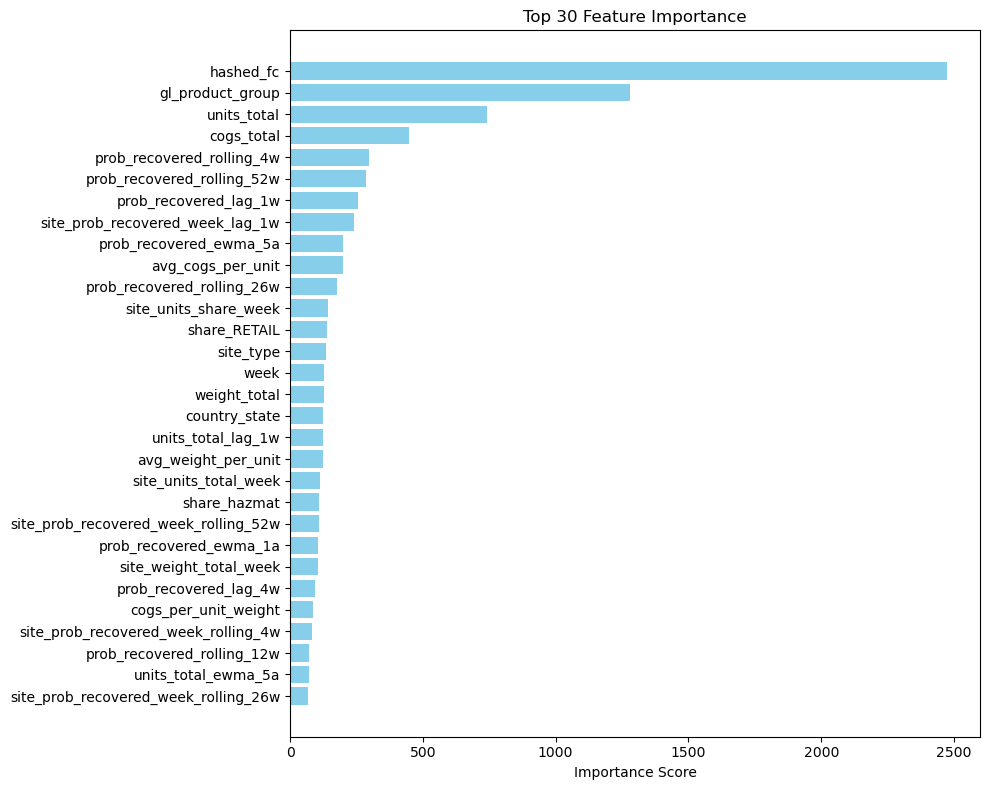

In [32]:
importance = model_with_current_inventory.get_booster().get_score(importance_type='weight')

importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

top_n = 30
plt.figure(figsize=(10, 8))
plt.barh(
    importance_df['Feature'].head(top_n)[::-1],
    importance_df['Importance'].head(top_n)[::-1],
    color='skyblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance')
plt.tight_layout()
plt.show()

In [33]:
top_30_features = importance_df['Feature'].head(top_n).tolist()
print("Top 30 features by importance:")
for i, feature in enumerate(top_30_features, start=1):
    print(f"{i}. {feature}")

Top 30 features by importance:
1. hashed_fc
2. gl_product_group
3. units_total
4. cogs_total
5. prob_recovered_rolling_4w
6. prob_recovered_rolling_52w
7. prob_recovered_lag_1w
8. site_prob_recovered_week_lag_1w
9. prob_recovered_ewma_5a
10. avg_cogs_per_unit
11. prob_recovered_rolling_26w
12. site_units_share_week
13. share_RETAIL
14. site_type
15. week
16. weight_total
17. country_state
18. units_total_lag_1w
19. avg_weight_per_unit
20. site_units_total_week
21. share_hazmat
22. site_prob_recovered_week_rolling_52w
23. prob_recovered_ewma_1a
24. site_weight_total_week
25. prob_recovered_lag_4w
26. cogs_per_unit_weight
27. site_prob_recovered_week_rolling_4w
28. prob_recovered_rolling_12w
29. units_total_ewma_5a
30. site_prob_recovered_week_rolling_26w


## Hyperparameter Tuning

In [23]:
!pip install optuna-integration


In [25]:
import optuna
from optuna.integration import XGBoostPruningCallback

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [35]:
# Use top 30 features for tuning to speed up trials and reduce noise

def objective(trial: optuna.Trial) -> float:

    X_train = cast_categoricals(df_train.select(top_30_features).to_pandas())
    X_val   = cast_categoricals(df_test.select(top_30_features).to_pandas())

    y_train = df_train[target_col].to_pandas().values
    y_val   = df_test[target_col].to_pandas().values

    # logit-transform the target 
    y_train_logit = logit(y_train)
    y_val_logit   = logit(y_val)

    params = {
        "objective": "reg:squarederror",
        "tree_method": "hist",
        "enable_categorical": True,
        "random_state": 42,
        "n_estimators": 500,           # ← lower ceiling; early stopping handles the rest
        "early_stopping_rounds": 30,   # ← tighter; stops faster on bad trials
        "eval_metric": prob_mae,
        "callbacks": [XGBoostPruningCallback(trial, "validation_0-prob_mae")],
        "max_depth":        trial.suggest_int("max_depth", 3, 8),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 50),
        "gamma":            trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "max_delta_step":   trial.suggest_int("max_delta_step", 0, 10),
    }

    model = XGBRegressor(**params)
    model.fit(
        X_train, y_train_logit,
        eval_set=[(X_val, y_val_logit)],
        verbose=False,
    )

    preds = np.clip(sigmoid(model.predict(X_val)), 0.0, 1.0)
    y_val_prob = sigmoid(y_val)
    return float(mean_absolute_error(y_val_prob, preds))

In [36]:
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10, interval_steps=5),
    study_name="xgb_recovery_propensity",
)

study.optimize(
    objective,
    n_trials=50,
    timeout=7200,  # 2 hours
    show_progress_bar=True,
)

print(f"\nBest MAE:    {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best MAE:    0.4836
Best params: {'max_depth': 8, 'learning_rate': 0.11511579879447058, 'subsample': 0.6780456116674968, 'colsample_bytree': 0.8410345350829652, 'min_child_weight': 31, 'gamma': 4.970029704981115, 'reg_alpha': 0.016894004126676365, 'reg_lambda': 0.0014441715954420077, 'max_delta_step': 7}


In [37]:
study.best_params

{'max_depth': 8,
 'learning_rate': 0.11511579879447058,
 'subsample': 0.6780456116674968,
 'colsample_bytree': 0.8410345350829652,
 'min_child_weight': 31,
 'gamma': 4.970029704981115,
 'reg_alpha': 0.016894004126676365,
 'reg_lambda': 0.0014441715954420077,
 'max_delta_step': 7}

In [13]:
def train_model_tuned(
    df_train: pl.DataFrame,
    df_test: pl.DataFrame,
    feature_cols: list[str],
    target_col: str
):

    start = time.perf_counter()

    X_train = cast_categoricals(df_train.select(['hashed_fc', 'gl_product_group'] + feature_cols).to_pandas())
    X_val   = cast_categoricals(df_test.select(['hashed_fc', 'gl_product_group'] + feature_cols).to_pandas())

    y_train = df_train[target_col].to_pandas().values
    y_val   = df_test[target_col].to_pandas().values

    # logit-transform the target 
    y_train_logit = logit(y_train)
    y_val_logit   = logit(y_val)

   
    # fit model 
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=8,
        learning_rate=0.11511579879447058,
        subsample=0.6780456116674968,
        colsample_bytree=0.8410345350829652,
        min_child_weight=31,
        gamma = 4.970029704981115,
        reg_alpha=0.016894004126676365,
        reg_lambda = 0.0014441715954420077,
        tree_method="hist",
        enable_categorical=True,
        random_state=42,
        early_stopping_rounds=50,
        eval_metric=prob_mae
    )

    model.fit(
        X_train, y_train_logit,
        eval_set=[(X_val, y_val_logit)],
        verbose=100,
            )

    # predict & back-transform
    preds_logit = model.predict(X_val)
    preds       = sigmoid(preds_logit)
    preds       = np.clip(preds, 0.0, 1.0)  # safety clip for edge cases

    # metrics
    mae  = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2   = r2_score(y_val, preds)

    elapsed = (time.perf_counter() - start) / 60
    print(f"\nTotal time: {elapsed:.1f} min")

    return model, X_val, y_val, preds, mae, rmse, r2

In [14]:
model_with_current_inventory_tuned, X_val, y_val, preds, mae, rmse, r2 = train_model_tuned(
    df_train, df_test, feature_cols, target_col
)
print(f"Validation MAE: {mae:.4f}")
print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation R²: {r2:.4f}")

[0]	validation_0-rmse:6.82128	validation_0-prob_mae:0.08672
[94]	validation_0-rmse:3.90156	validation_0-prob_mae:0.03591

Total time: 2.5 min
Validation MAE: 0.0335
Validation RMSE: 0.1259
Validation R²: 0.7191


In [15]:
save_model_to_s3(model_with_current_inventory_tuned, 'msds-26.2-data', 'model/tuned_xgboost_model_current_inventory_with_site_features.joblib')

## Model Diagnostics

In [22]:
preds = np.round(preds, 4)  # round predictions to 4 decimal places
residuals = preds - y_val

diagnostics = df_test.with_columns([
    pl.Series("y_true",       y_val),
    pl.Series("y_pred",       preds),
    pl.Series("residual",     residuals),
    pl.Series("abs_residual", np.abs(residuals)),
]).with_columns([
    pl.when(pl.col("units_total") < 10).then(pl.lit("< 10"))
      .when(pl.col("units_total") < 100).then(pl.lit("10–100"))
      .when(pl.col("units_total") < 1000).then(pl.lit("100–1k"))
      .otherwise(pl.lit("> 1k"))
      .alias("volume_bucket"),

    pl.when(pl.col("y_true") == 0).then(pl.lit("zero"))
      .when(pl.col("y_true") < 0.1).then(pl.lit("0–10%"))
      .when(pl.col("y_true") < 0.3).then(pl.lit("10–30%"))
      .when(pl.col("y_true") < 0.6).then(pl.lit("30–60%"))
      .otherwise(pl.lit("> 60%"))
      .alias("rate_bucket"),
])

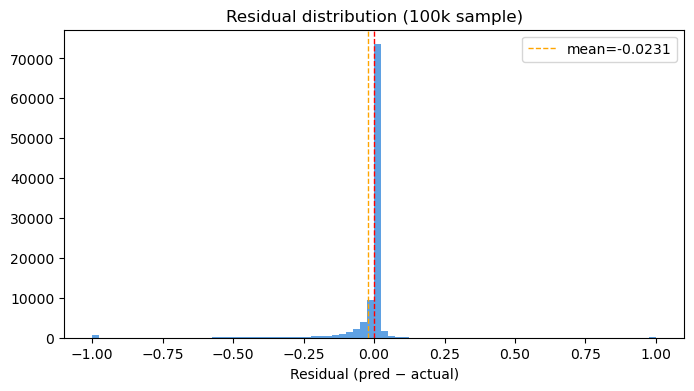

In [25]:
sample_idx = np.random.choice(len(residuals), size=100_000, replace=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residuals[sample_idx], bins=80, color="#378ADD", edgecolor="none", alpha=0.8)
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.axvline(residuals.mean(), color="orange", linestyle="--", linewidth=1,
           label=f"mean={residuals.mean():.4f}")
ax.set_xlabel("Residual (pred − actual)")
ax.set_title("Residual distribution (100k sample)")
ax.legend()
plt.show()

In [26]:
def stratified_mae(df: pl.DataFrame, group_col: str) -> pl.DataFrame:
    return (
        df.group_by(group_col)
        .agg([
            pl.col("abs_residual").mean().alias("mae").round(4),
            pl.col("abs_residual").median().alias("median_ae").round(4),
            pl.col("units_total").sum().alias("total_units"),
            pl.len().alias("n_rows"),
        ])
        .sort("mae", descending=True)
    )

print("── By volume bucket ──")
print(stratified_mae(diagnostics, "volume_bucket"))

print("\n── By true rate bucket ──")
print(stratified_mae(diagnostics, "rate_bucket"))

print("\n── By GL ──")
print(stratified_mae(diagnostics, "gl_product_group").head(15))

print("\n── By site type ──")
print(stratified_mae(diagnostics, "site_type"))

print("\n── By country ──")
print(stratified_mae(diagnostics, "country"))

── By volume bucket ──
shape: (4, 5)
┌───────────────┬────────┬───────────┬─────────────┬────────┐
│ volume_bucket ┆ mae    ┆ median_ae ┆ total_units ┆ n_rows │
│ ---           ┆ ---    ┆ ---       ┆ ---         ┆ ---    │
│ str           ┆ f64    ┆ f64       ┆ f64         ┆ u32    │
╞═══════════════╪════════╪═══════════╪═════════════╪════════╡
│ 10–100        ┆ 0.0408 ┆ 0.0       ┆ 2.7478e7    ┆ 767849 │
│ < 10          ┆ 0.036  ┆ 0.0       ┆ 4.2259e6    ┆ 709706 │
│ 100–1k        ┆ 0.0302 ┆ 0.0013    ┆ 1.8612e8    ┆ 530913 │
│ > 1k          ┆ 0.0227 ┆ 0.0107    ┆ 9.8740e9    ┆ 533748 │
└───────────────┴────────┴───────────┴─────────────┴────────┘

── By true rate bucket ──
shape: (5, 5)
┌─────────────┬────────┬───────────┬─────────────┬─────────┐
│ rate_bucket ┆ mae    ┆ median_ae ┆ total_units ┆ n_rows  │
│ ---         ┆ ---    ┆ ---       ┆ ---         ┆ ---     │
│ str         ┆ f64    ┆ f64       ┆ f64         ┆ u32     │
╞═════════════╪════════╪═══════════╪═════════════╪════════

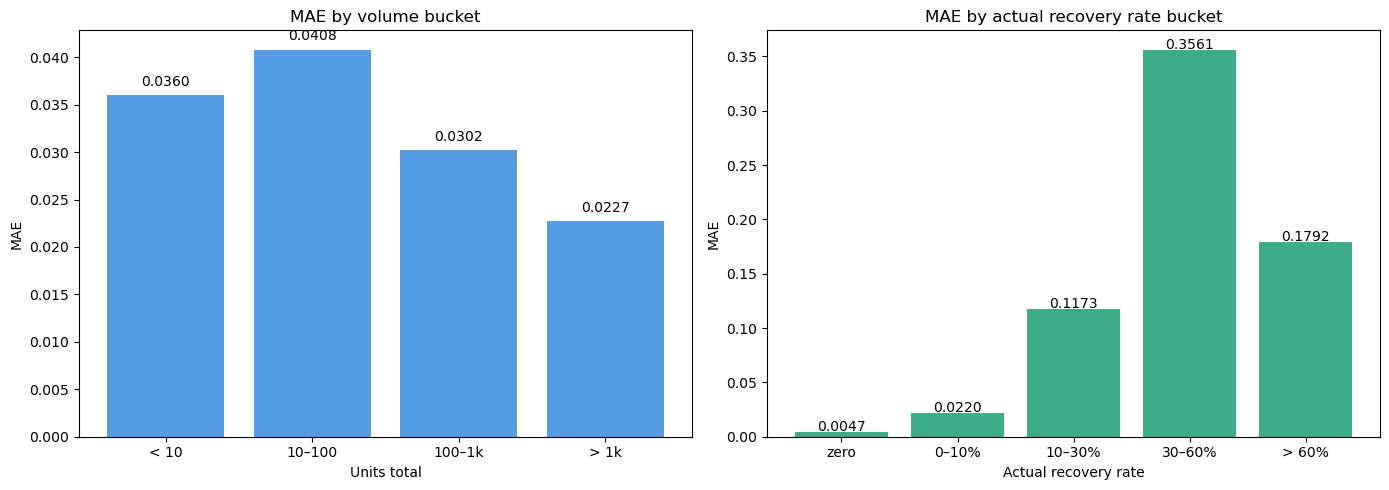

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vol_mae = stratified_mae(diagnostics, "volume_bucket").to_pandas()
rate_mae = stratified_mae(diagnostics, "rate_bucket").to_pandas()

vol_order  = ["< 10", "10-100", "100-1k", "> 1k"]
rate_order = ["zero", "0-10%", "10-30%", "30-60%", "> 60%"]

vol_mae  = vol_mae.set_index("volume_bucket").reindex(vol_order)
rate_mae = rate_mae.set_index("rate_bucket").reindex(rate_order)

axes[0].bar(vol_mae.index, vol_mae["mae"], color="#378ADD", alpha=0.85)
axes[0].set_title("MAE by volume bucket")
axes[0].set_xlabel("Units total")
axes[0].set_ylabel("MAE")
for i, v in enumerate(vol_mae["mae"]):
    axes[0].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=10)

axes[1].bar(rate_mae.index, rate_mae["mae"], color="#1D9E75", alpha=0.85)
axes[1].set_title("MAE by actual recovery rate bucket")
axes[1].set_xlabel("Actual recovery rate")
axes[1].set_ylabel("MAE")
for i, v in enumerate(rate_mae["mae"]):
    axes[1].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

In [28]:
# Check what the model actually predicts for high-recovery rows
high_recovery = diagnostics.filter(pl.col("rate_bucket") == "> 60%")

print(
    high_recovery
    .select([
        pl.col("y_pred").mean().alias("mean_predicted"),
        pl.col("y_pred").median().alias("median_predicted"),
        pl.col("y_true").mean().alias("mean_actual"),
        pl.col("y_pred").quantile(0.9).alias("p90_predicted"),
    ])
)

shape: (1, 4)
┌────────────────┬──────────────────┬─────────────┬───────────────┐
│ mean_predicted ┆ median_predicted ┆ mean_actual ┆ p90_predicted │
│ ---            ┆ ---              ┆ ---         ┆ ---           │
│ f32            ┆ f32              ┆ f64         ┆ f32           │
╞════════════════╪══════════════════╪═════════════╪═══════════════╡
│ 0.803383       ┆ 1.0              ┆ 0.97782     ┆ 1.0           │
└────────────────┴──────────────────┴─────────────┴───────────────┘


In [29]:
mid_range = diagnostics.filter(pl.col("rate_bucket") == "30–60%")

print(
    mid_range
    .select([
        pl.col("y_pred").mean().alias("mean_predicted"),
        pl.col("y_pred").median().alias("median_predicted"),
        pl.col("y_true").mean().alias("mean_actual"),
        pl.col("y_pred").quantile(0.25).alias("p25_predicted"),
        pl.col("y_pred").quantile(0.75).alias("p75_predicted"),
        pl.col("y_pred").quantile(0.9).alias("p90_predicted"),
    ])
)

# what is the model predicting for these rows — near 0, near 1, or spread?
print(
    mid_range
    .with_columns(
        pl.when(pl.col("y_pred") < 0.1).then(pl.lit("< 10%"))
          .when(pl.col("y_pred") < 0.3).then(pl.lit("10–30%"))
          .when(pl.col("y_pred") < 0.6).then(pl.lit("30–60%"))
          .when(pl.col("y_pred") < 0.9).then(pl.lit("60–90%"))
          .otherwise(pl.lit("> 90%"))
          .alias("pred_bucket")
    )
    .group_by("pred_bucket")
    .agg(pl.len().alias("n_rows"))
    .sort("pred_bucket")
)

shape: (1, 6)
┌────────────────┬──────────────────┬─────────────┬───────────────┬───────────────┬───────────────┐
│ mean_predicted ┆ median_predicted ┆ mean_actual ┆ p25_predicted ┆ p75_predicted ┆ p90_predicted │
│ ---            ┆ ---              ┆ ---         ┆ ---           ┆ ---           ┆ ---           │
│ f32            ┆ f32              ┆ f64         ┆ f32           ┆ f32           ┆ f32           │
╞════════════════╪══════════════════╪═════════════╪═══════════════╪═══════════════╪═══════════════╡
│ 0.085576       ┆ 0.0108           ┆ 0.41796     ┆ 0.0005        ┆ 0.0963        ┆ 0.2434        │
└────────────────┴──────────────────┴─────────────┴───────────────┴───────────────┴───────────────┘
shape: (5, 2)
┌─────────────┬────────┐
│ pred_bucket ┆ n_rows │
│ ---         ┆ ---    │
│ str         ┆ u32    │
╞═════════════╪════════╡
│ 10–30%      ┆ 8715   │
│ 30–60%      ┆ 2534   │
│ 60–90%      ┆ 957    │
│ < 10%       ┆ 39726  │
│ > 90%       ┆ 578    │
└─────────────┴───────

The model is poor at predicting mid range and high recovery rate, often predicting values close to 0 or 1. This is because training data with actual recovery rate at 0 or near 0 dominates. <br>
There are two possible courses of action: <br>
- 2-stage model (stage 1 is a classifier trained on all row, stage 2 is a regressor trained only on non-zero rows).
- Add weight to the mid range rows.

## Train Model with Sample Weights

In [ ]:
def compute_sample_weights(y: np.ndarray) -> np.ndarray:

    weights = np.ones(len(y))
    weights[(y > 0.0)  & (y < 0.1)]  = 3.0   # low recovery — slightly up-weight
    weights[(y >= 0.1) & (y < 0.3)]  = 8.0   # model sees these but still weak
    weights[(y >= 0.3) & (y < 0.6)]  = 20.0  # primary problem — strongest weight
    weights[(y >= 0.6)]               = 5.0   # already well-predicted, mild boost
    return weights


In [ ]:
def train_model_tuned_with_weights(
    df_train: pl.DataFrame,
    df_test: pl.DataFrame,
    feature_cols: list[str],
    target_col: str
):

    start = time.perf_counter()

    X_train = cast_categoricals(df_train.select(['hashed_fc', 'gl_product_group'] + feature_cols).to_pandas())
    X_val   = cast_categoricals(df_test.select(['hashed_fc', 'gl_product_group'] + feature_cols).to_pandas())

    y_train = df_train[target_col].to_pandas().values
    y_val   = df_test[target_col].to_pandas().values

    # logit-transform the target 
    y_train_logit = logit(y_train)
    y_val_logit   = logit(y_val)

   
    # fit model 
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=8,
        learning_rate=0.11511579879447058,
        subsample=0.6780456116674968,
        colsample_bytree=0.8410345350829652,
        min_child_weight=31,
        gamma = 4.970029704981115,
        reg_alpha=0.016894004126676365,
        reg_lambda = 0.0014441715954420077,
        tree_method="hist",
        enable_categorical=True,
        random_state=42,
        early_stopping_rounds=50,
        eval_metric=prob_mae
    )

    model.fit(
        X_train, y_train_logit,
        sample_weight=compute_sample_weights(y_train),
        eval_set=[(X_val, y_val_logit)],
        verbose=100,
)

    # predict & back-transform
    preds_logit = model.predict(X_val)
    preds       = sigmoid(preds_logit)
    preds       = np.clip(preds, 0.0, 1.0)  # safety clip for edge cases

    # metrics
    mae  = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2   = r2_score(y_val, preds)

    elapsed = (time.perf_counter() - start) / 60
    print(f"\nTotal time: {elapsed:.1f} min")

    return model, X_val, y_val, preds, mae, rmse, r2

In [31]:
model_with_current_inventory_tuned_weighted, X_val, y_val, preds, mae, rmse, r2 = train_model_tuned_with_weights(
    df_train, df_test, feature_cols, target_col
)
print(f"Validation MAE: {mae:.4f}")
print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation R²: {r2:.4f}")

[0]	validation_0-rmse:8.75285	validation_0-prob_mae:0.08123
[76]	validation_0-rmse:4.42794	validation_0-prob_mae:0.04061

Total time: 2.2 min
Validation MAE: 0.0356
Validation RMSE: 0.1264
Validation R²: 0.7168


In [38]:
preds = np.round(preds, 4)  # round predictions to 4 decimal places
residuals = preds - y_val

diagnostics_weighted = df_test.with_columns([
    pl.Series("y_true",       y_val),
    pl.Series("y_pred",       preds),
    pl.Series("residual",     residuals),
    pl.Series("abs_residual", np.abs(residuals)),
]).with_columns([
    pl.when(pl.col("units_total") < 10).then(pl.lit("< 10"))
      .when(pl.col("units_total") < 100).then(pl.lit("10–100"))
      .when(pl.col("units_total") < 1000).then(pl.lit("100–1k"))
      .otherwise(pl.lit("> 1k"))
      .alias("volume_bucket"),

    pl.when(pl.col("y_true") == 0).then(pl.lit("zero"))
      .when(pl.col("y_true") < 0.1).then(pl.lit("0–10%"))
      .when(pl.col("y_true") < 0.3).then(pl.lit("10–30%"))
      .when(pl.col("y_true") < 0.6).then(pl.lit("30–60%"))
      .otherwise(pl.lit("> 60%"))
      .alias("rate_bucket"),
])

In [40]:
print(stratified_mae(diagnostics_weighted, "rate_bucket"))
print(stratified_mae(diagnostics_weighted, "volume_bucket"))

shape: (5, 5)
┌─────────────┬────────┬───────────┬─────────────┬─────────┐
│ rate_bucket ┆ mae    ┆ median_ae ┆ total_units ┆ n_rows  │
│ ---         ┆ ---    ┆ ---       ┆ ---         ┆ ---     │
│ str         ┆ f64    ┆ f64       ┆ f64         ┆ u32     │
╞═════════════╪════════╪═══════════╪═════════════╪═════════╡
│ 30–60%      ┆ 0.2364 ┆ 0.2303    ┆ 2.7930e7    ┆ 52510   │
│ > 60%       ┆ 0.1242 ┆ 0.0       ┆ 6.8230e7    ┆ 152543  │
│ 10–30%      ┆ 0.0884 ┆ 0.0639    ┆ 5.0362e8    ┆ 162030  │
│ 0–10%       ┆ 0.0311 ┆ 0.0144    ┆ 8.9007e9    ┆ 569051  │
│ zero        ┆ 0.0169 ┆ 0.0       ┆ 5.9136e8    ┆ 1606082 │
└─────────────┴────────┴───────────┴─────────────┴─────────┘
shape: (4, 5)
┌───────────────┬────────┬───────────┬─────────────┬────────┐
│ volume_bucket ┆ mae    ┆ median_ae ┆ total_units ┆ n_rows │
│ ---           ┆ ---    ┆ ---       ┆ ---         ┆ ---    │
│ str           ┆ f64    ┆ f64       ┆ f64         ┆ u32    │
╞═══════════════╪════════╪═══════════╪═════════════╪═

In [35]:
def evaluate_weighted(diagnostics: pl.DataFrame) -> None:

    # volume-weighted MAE — weights each row by its unit volume
    vw_mae = (
        diagnostics
        .select([
            (pl.col("abs_residual") * pl.col("units_total")).sum() /
            pl.col("units_total").sum()
        ])
        .item()
    )

    # recovery-weighted MAE — weights each row by actual recovery rate
    # captures whether we're accurate where recovery is high
    rw_mae = (
        diagnostics
        .filter(pl.col("y_true") > 0)
        .select([
            (pl.col("abs_residual") * pl.col("y_true")).sum() /
            pl.col("y_true").sum()
        ])
        .item()
    )

    print(f"Plain MAE:              {diagnostics['abs_residual'].mean():.4f}")
    print(f"Volume-weighted MAE:    {vw_mae:.4f}")
    print(f"Recovery-weighted MAE:  {rw_mae:.4f}")


In [41]:
evaluate_weighted(diagnostics_weighted)

Plain MAE:              0.0356
Volume-weighted MAE:    0.0189
Recovery-weighted MAE:  0.1204


In [42]:
# Adjust weights
def compute_sample_weights(y: np.ndarray) -> np.ndarray:
    weights = np.ones(len(y))
    weights[y == 0]                      = 2.0   # ← explicit zero weight; raise to protect zeros
    weights[(y > 0.0) & (y < 0.1)]      = 3.0
    weights[(y >= 0.1) & (y < 0.3)]     = 8.0
    weights[(y >= 0.3) & (y < 0.6)]     = 20.0
    weights[(y >= 0.6)]                  = 5.0
    return weights

In [43]:
model_with_current_inventory_tuned_weighted_adj, X_val, y_val, preds, mae, rmse, r2 = train_model_tuned_with_weights(
    df_train, df_test, feature_cols, target_col
)
print(f"Validation MAE: {mae:.4f}")
print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation R²: {r2:.4f}")

[0]	validation_0-rmse:7.68403	validation_0-prob_mae:0.08417
[75]	validation_0-rmse:4.01218	validation_0-prob_mae:0.03745

Total time: 2.1 min
Validation MAE: 0.0310
Validation RMSE: 0.1159
Validation R²: 0.7618


In [44]:
preds = np.round(preds, 4)  # round predictions to 4 decimal places
residuals = preds - y_val

diagnostics_weighted_adj = df_test.with_columns([
    pl.Series("y_true",       y_val),
    pl.Series("y_pred",       preds),
    pl.Series("residual",     residuals),
    pl.Series("abs_residual", np.abs(residuals)),
]).with_columns([
    pl.when(pl.col("units_total") < 10).then(pl.lit("< 10"))
      .when(pl.col("units_total") < 100).then(pl.lit("10–100"))
      .when(pl.col("units_total") < 1000).then(pl.lit("100–1k"))
      .otherwise(pl.lit("> 1k"))
      .alias("volume_bucket"),

    pl.when(pl.col("y_true") == 0).then(pl.lit("zero"))
      .when(pl.col("y_true") < 0.1).then(pl.lit("0–10%"))
      .when(pl.col("y_true") < 0.3).then(pl.lit("10–30%"))
      .when(pl.col("y_true") < 0.6).then(pl.lit("30–60%"))
      .otherwise(pl.lit("> 60%"))
      .alias("rate_bucket"),
])

In [46]:
print(stratified_mae(diagnostics_weighted_adj, "rate_bucket"))
print(stratified_mae(diagnostics_weighted_adj, "volume_bucket"))

shape: (5, 5)
┌─────────────┬────────┬───────────┬─────────────┬─────────┐
│ rate_bucket ┆ mae    ┆ median_ae ┆ total_units ┆ n_rows  │
│ ---         ┆ ---    ┆ ---       ┆ ---         ┆ ---     │
│ str         ┆ f64    ┆ f64       ┆ f64         ┆ u32     │
╞═════════════╪════════╪═══════════╪═════════════╪═════════╡
│ 30–60%      ┆ 0.2743 ┆ 0.278     ┆ 2.7930e7    ┆ 52510   │
│ > 60%       ┆ 0.1543 ┆ 0.0       ┆ 6.8230e7    ┆ 152543  │
│ 10–30%      ┆ 0.0892 ┆ 0.0758    ┆ 5.0362e8    ┆ 162030  │
│ 0–10%       ┆ 0.0233 ┆ 0.0142    ┆ 8.9007e9    ┆ 569051  │
│ zero        ┆ 0.0082 ┆ 0.0       ┆ 5.9136e8    ┆ 1606082 │
└─────────────┴────────┴───────────┴─────────────┴─────────┘
shape: (4, 5)
┌───────────────┬────────┬───────────┬─────────────┬────────┐
│ volume_bucket ┆ mae    ┆ median_ae ┆ total_units ┆ n_rows │
│ ---           ┆ ---    ┆ ---       ┆ ---         ┆ ---    │
│ str           ┆ f64    ┆ f64       ┆ f64         ┆ u32    │
╞═══════════════╪════════╪═══════════╪═════════════╪═

In [48]:
evaluate_weighted(diagnostics_weighted_adj)

Plain MAE:              0.0310
Volume-weighted MAE:    0.0175
Recovery-weighted MAE:  0.1438
